In [28]:
from langchain_ollama import ChatOllama
from typing import List, Annotated, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_core.messages import SystemMessage, HumanMessage

In [29]:
class extractState(BaseModel):
    domains: List[str] = Field(
        description="List down the domains which are relevant based on the user query (e.g., coins, whispers, ships)."
    )
    threat_level: Literal["low", "medium", "high"] = Field(
        description="Based on the user query, determine the threat level."
    )

class State(TypedDict):
    incoming_scroll : str
    extracted: extractState
    council_proposals: Annotated[List[dict], operator.add]
    final_decree: str

In [30]:
llm = ChatOllama(model="llama3")

In [31]:
def extractor(state: State) -> State:
    SYSTEM_PROMPT = """You are a scribe in the royal court. Your task is to read the incoming scrolls and extract relevant information to assist the council in making informed decisions. For each scroll, identify the domains it pertains to (coins, whispers, ships) and assess and tell the masters about, the threat level (low, medium, high) based on the content and tone of the scroll."""
    response = llm.with_structured_output(extractState).invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Scroll: {state['incoming_scroll']}")
    ])
    return {"extracted": response}

def fanout(state: State) -> list:
    extracted_data = state['extracted'] 
    threat = extracted_data.threat_level
    
    return [
        Send("worker", {
            'domain': domain, 
            'scroll': state['incoming_scroll'], 
            'threat_level': threat
        }) 
        for domain in extracted_data.domains
    ]

def worker_node(payload: dict) -> dict:
    domain = payload['domain']
    scroll = payload['scroll']
    threat_level = payload['threat_level']
    SYSTEM_PROMPT = f"""You are the {domain} master in the royal council. Your task is to read the incoming scrolls related to your domain and propose actionable insights or decisions to the council based on the content of the scroll. Provide clear and concise proposals that can help the council make informed decisions regarding {domain}. The threat level of the scroll is {threat_level}, so take that into consideration when formulating your proposal."""
    response = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Scroll: {scroll}")
    ])
    return {"council_proposals" : [{"role" : f"Master of {domain.capitalize()}", "proposal": response.content}]}

def reducer(state: State) -> dict:
    SYSTEM_PROMPT = """You are the head of the royal council. Your task is to review the proposals from the domain masters and synthesize them into a final decree that can be issued to the kingdom. Consider the insights and recommendations provided by each master, and craft a decree that addresses the concerns raised in the scroll while also taking into account the threat level. The decree should be clear, actionable, and provide guidance to the citizens of the kingdom."""
    proposals = "\n\n".join([f"{proposal['role']} says: {proposal['proposal']}" for proposal in state['council_proposals']])
    response = llm.invoke([
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Proposals: {proposals}")
    ])
    return {"final_decree": response.content}

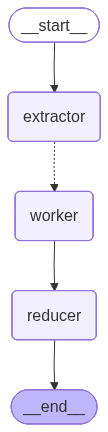

In [32]:
graph = StateGraph(State)
graph.add_node("extractor", extractor)
graph.add_node("worker", worker_node)
graph.add_node("reducer", reducer)

graph.add_edge(START, "extractor")
graph.add_conditional_edges("extractor", fanout, ["worker"])
graph.add_edge("worker", "reducer")
graph.add_edge("reducer", END)

flow = graph.compile()
flow

In [33]:
initial_state = {
    "incoming_scroll": (
        """Urgent tidings from the Stepstones. A fleet of Lyseni pirates has blockaded
        the primary trade lanes, halting all merchant vessels bound for King's Landing.
        They demand a ransom of 50,000 golden dragons to lift the blockade. Furthermore,
        my informants in the local taverns whisper that this pirate king is secretly being
        funded by an exiled Targaryen sympathizer looking to weaken the Crown's naval and 
        financial standing before launching an invasion."""
    )
}
result = flow.invoke(initial_state)


In [34]:
result

{'incoming_scroll': "Urgent tidings from the Stepstones. A fleet of Lyseni pirates has blockaded\n        the primary trade lanes, halting all merchant vessels bound for King's Landing.\n        They demand a ransom of 50,000 golden dragons to lift the blockade. Furthermore,\n        my informants in the local taverns whisper that this pirate king is secretly being\n        funded by an exiled Targaryen sympathizer looking to weaken the Crown's naval and \n        financial standing before launching an invasion.",
 'extracted': extractState(domains=['coins', 'ships', 'whispers'], threat_level='high'),
 'council_proposals': [{'role': 'Master of Coins',
   'proposal': "**Coins Master's Proposal**\n\nTo: The Royal Council of King's Landing\n\nSubject: Urgent Response to Pirate Blockade on Stepstones Trade Lanes\n\n**Threat Level:** High (Potential destabilization of trade, economic impact, and threat to national security)\n\n**Recommendations:**\n\n1. **Immediate Ransom Payment:** Authori